# 02 — Modelo de Demanda (V2 — fix)

**Cambios sobre V1:**
1. Filtramos productos con al menos 4 semanas de histórico en train (resuelve cold-start).
2. Recomputamos rolling means correctamente (sin doble shift).
3. Aplicamos log-transform a `units_sold` para estabilizar la varianza (estándar en retail forecasting).

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from src.config import PROCESSED_DIR, RESULTS_DIR, FIGURES_DIR, RANDOM_SEED

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
np.random.seed(RANDOM_SEED)

## 1. Cargar feature store

In [2]:
weekly = pd.read_parquet(PROCESSED_DIR / 'weekly_sales.parquet')
articles = pd.read_parquet(PROCESSED_DIR / 'article_features.parquet')

print(f'Weekly sales: {weekly.shape}')
print(f'Articles:     {articles.shape}')
weekly = weekly.sort_values(['article_id', 'week']).reset_index(drop=True)

Weekly sales: (2104136, 4)
Articles:     (75321, 10)


## 2. Filtro: productos con histórico suficiente en train

Solo entrenamos en productos con al menos 4 semanas ANTES del corte de train. Esto evita cold-start.

In [3]:
TRAIN_END = pd.Timestamp('2020-06-22')
VAL_END = pd.Timestamp('2020-08-22')

weeks_in_train = (
    weekly[weekly['week'] <= TRAIN_END]
    .groupby('article_id', observed=True).size()
)
valid_articles = weeks_in_train[weeks_in_train >= 4].index

print(f'Productos antes del filtro: {weekly["article_id"].nunique():,}')
print(f'Productos válidos (>=4 sem en train): {len(valid_articles):,}')

weekly = weekly[weekly['article_id'].isin(valid_articles)].copy()
print(f'Filas tras filtro: {len(weekly):,}')

Productos antes del filtro: 75,321
Productos válidos (>=4 sem en train): 71,881
Filas tras filtro: 2,066,745


## 3. Feature engineering temporal (corregido)

In [4]:
weekly = weekly.sort_values(['article_id', 'week']).reset_index(drop=True)
g = weekly.groupby('article_id', observed=True)['units_sold']

for lag in [1, 2, 4]:
    weekly[f'lag_{lag}'] = g.shift(lag)

for window in [4, 8]:
    weekly[f'rolling_mean_{window}'] = (
        g.shift(1).rolling(window=window, min_periods=1).mean()
        .reset_index(level=0, drop=True)
    )

weekly['month'] = weekly['week'].dt.month
weekly['week_of_year'] = weekly['week'].dt.isocalendar().week.astype(int)
weekly['quarter'] = weekly['week'].dt.quarter
weekly['month_sin'] = np.sin(2 * np.pi * weekly['month'] / 12)
weekly['month_cos'] = np.cos(2 * np.pi * weekly['month'] / 12)

first_week = weekly.groupby('article_id', observed=True)['week'].transform('min')
weekly['weeks_in_catalog'] = ((weekly['week'] - first_week).dt.days / 7).astype(int)

print(f'Shape: {weekly.shape}')
weekly[['article_id', 'week', 'units_sold', 'lag_1', 'rolling_mean_4']].head(8)

Shape: (2066745, 15)


,article_id,week,units_sold,lag_1,rolling_mean_4
0,0108775015,2018-09-17,115,NaN,NaN
1,0108775015,2018-09-24,547,115.0,115.000000
2,0108775015,2018-10-01,315,547.0,331.000000
3,0108775015,2018-10-08,360,315.0,325.666667
4,0108775015,2018-10-15,259,360.0,334.250000
5,0108775015,2018-10-22,434,259.0,370.250000
6,0108775015,2018-10-29,373,434.0,342.000000
7,0108775015,2018-11-05,312,373.0,356.500000


## 4. Join con metadata + log target

El log-transform es **clave**: `units_sold` tiene una distribución muy sesgada (la mayoría de productos vende 1-5 unidades, algunos vendrán cientos). Aprender en log estabiliza la varianza y mejora drásticamente las predicciones.

In [5]:
category_cols = [
    'product_group_name', 'product_type_name', 'colour_group_name',
    'department_name', 'index_group_name', 'garment_group_name',
]

weekly = weekly.merge(articles[['article_id'] + category_cols], on='article_id', how='left')
for col in category_cols:
    weekly[col] = weekly[col].astype('category')

# Target en log
weekly['log_units'] = np.log1p(weekly['units_sold'])
for col in ['lag_1', 'lag_2', 'lag_4', 'rolling_mean_4', 'rolling_mean_8']:
    weekly[f'log_{col}'] = np.log1p(weekly[col])

print(f'Shape final: {weekly.shape}')

Shape final: (2066745, 27)


## 5. Split temporal

In [6]:
weekly_clean = weekly.dropna(subset=['lag_4', 'rolling_mean_8']).copy()

train = weekly_clean[weekly_clean['week'] <= TRAIN_END]
val = weekly_clean[(weekly_clean['week'] > TRAIN_END) & (weekly_clean['week'] <= VAL_END)]
test = weekly_clean[weekly_clean['week'] > VAL_END]

print(f'Train: {len(train):,} | {train["week"].min().date()} → {train["week"].max().date()}')
print(f'Val:   {len(val):,} | {val["week"].min().date()} → {val["week"].max().date()}')
print(f'Test:  {len(test):,} | {test["week"].min().date()} → {test["week"].max().date()}')

Train: 1,590,789 | 2018-10-15 → 2020-06-22
Val:   134,507 | 2020-06-29 → 2020-08-17
Test:  53,925 | 2020-08-24 → 2020-09-21


## 6. Métricas y baselines

In [7]:
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def evaluate(y_true, y_pred, name='Model'):
    metrics = {
        'model': name,
        'wape': float(wape(y_true, y_pred)),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
    }
    print(f'{name:30s} | WAPE: {metrics["wape"]:.3f} | MAE: {metrics["mae"]:.2f} | RMSE: {metrics["rmse"]:.2f}')
    return metrics

results = []
y_test = test['units_sold'].values

results.append(evaluate(y_test, test['lag_1'].values, 'Baseline: lag_1'))
results.append(evaluate(y_test, test['rolling_mean_4'].values, 'Baseline: rolling_mean_4'))

Baseline: lag_1                | WAPE: 0.565 | MAE: 4.93 | RMSE: 14.73
Baseline: rolling_mean_4       | WAPE: 0.926 | MAE: 8.09 | RMSE: 21.31


## 7. 🚀 LightGBM con log target

In [8]:
feature_cols = [
    'log_lag_1', 'log_lag_2', 'log_lag_4',
    'log_rolling_mean_4', 'log_rolling_mean_8',
    'month', 'week_of_year', 'quarter',
    'month_sin', 'month_cos',
    'weeks_in_catalog', 'avg_price',
] + category_cols

X_train, y_train_log = train[feature_cols], train['log_units']
X_val, y_val_log = val[feature_cols], val['log_units']
X_test = test[feature_cols]

print(f'Features ({len(feature_cols)})')

Features (18)


In [9]:
%%time
lgb_train = lgb.Dataset(X_train, y_train_log, categorical_feature=category_cols)
lgb_val = lgb.Dataset(X_val, y_val_log, categorical_feature=category_cols, reference=lgb_train)

params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_data_in_leaf': 100,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'bagging_freq': 5,
    'verbosity': -1,
    'seed': RANDOM_SEED,
}

model = lgb.train(
    params, lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_train, lgb_val], valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)],
)

Training until validation scores don't improve for 50 rounds
[100]	train's l1: 0.379769	val's l1: 0.361692
[200]	train's l1: 0.362315	val's l1: 0.352939
[300]	train's l1: 0.356746	val's l1: 0.351648
[400]	train's l1: 0.353553	val's l1: 0.351223
Early stopping, best iteration is:
[351]	train's l1: 0.355081	val's l1: 0.351196
CPU times: total: 11min 15s
Wall time: 46.5 s


In [10]:
# Predecir en log y deshacer
y_pred_log = model.predict(X_test, num_iteration=model.best_iteration)
y_pred_lgb = np.expm1(y_pred_log)
y_pred_lgb = np.clip(y_pred_lgb, 0, None)

results.append(evaluate(y_test, y_pred_lgb, 'LightGBM (log target)'))

LightGBM (log target)          | WAPE: 0.526 | MAE: 4.60 | RMSE: 16.12


## 8. Comparativa final

In [11]:
results_df = pd.DataFrame(results)
print('\n=== Resultados sobre el TEST SET ===')
print(results_df.to_string(index=False))

improvement = (results[0]['wape'] - results[-1]['wape']) / results[0]['wape'] * 100
print(f'\n✨ LightGBM mejora sobre baseline naive (lag_1) en un {improvement:.1f}% (WAPE)')


=== Resultados sobre el TEST SET ===
                   model     wape      mae      rmse
         Baseline: lag_1 0.564913 4.933426 14.731153
Baseline: rolling_mean_4 0.925901 8.085957 21.308378
   LightGBM (log target) 0.526187 4.595226 16.115462

✨ LightGBM mejora sobre baseline naive (lag_1) en un 6.9% (WAPE)


## 9. Feature importance

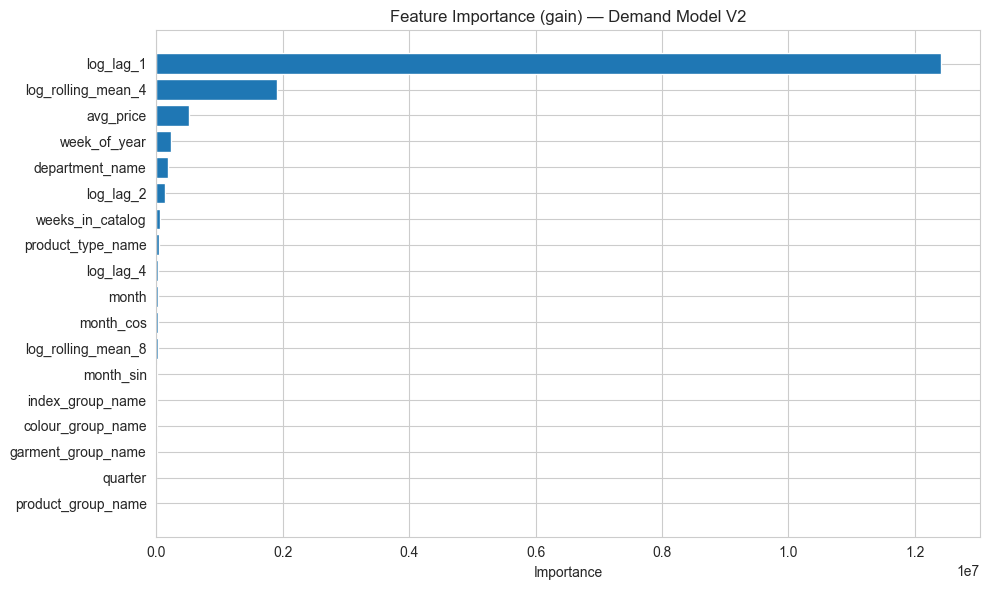

In [12]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'], importance_df['importance'])
ax.set_title('Feature Importance (gain) — Demand Model V2')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_demand_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Predicción vs real

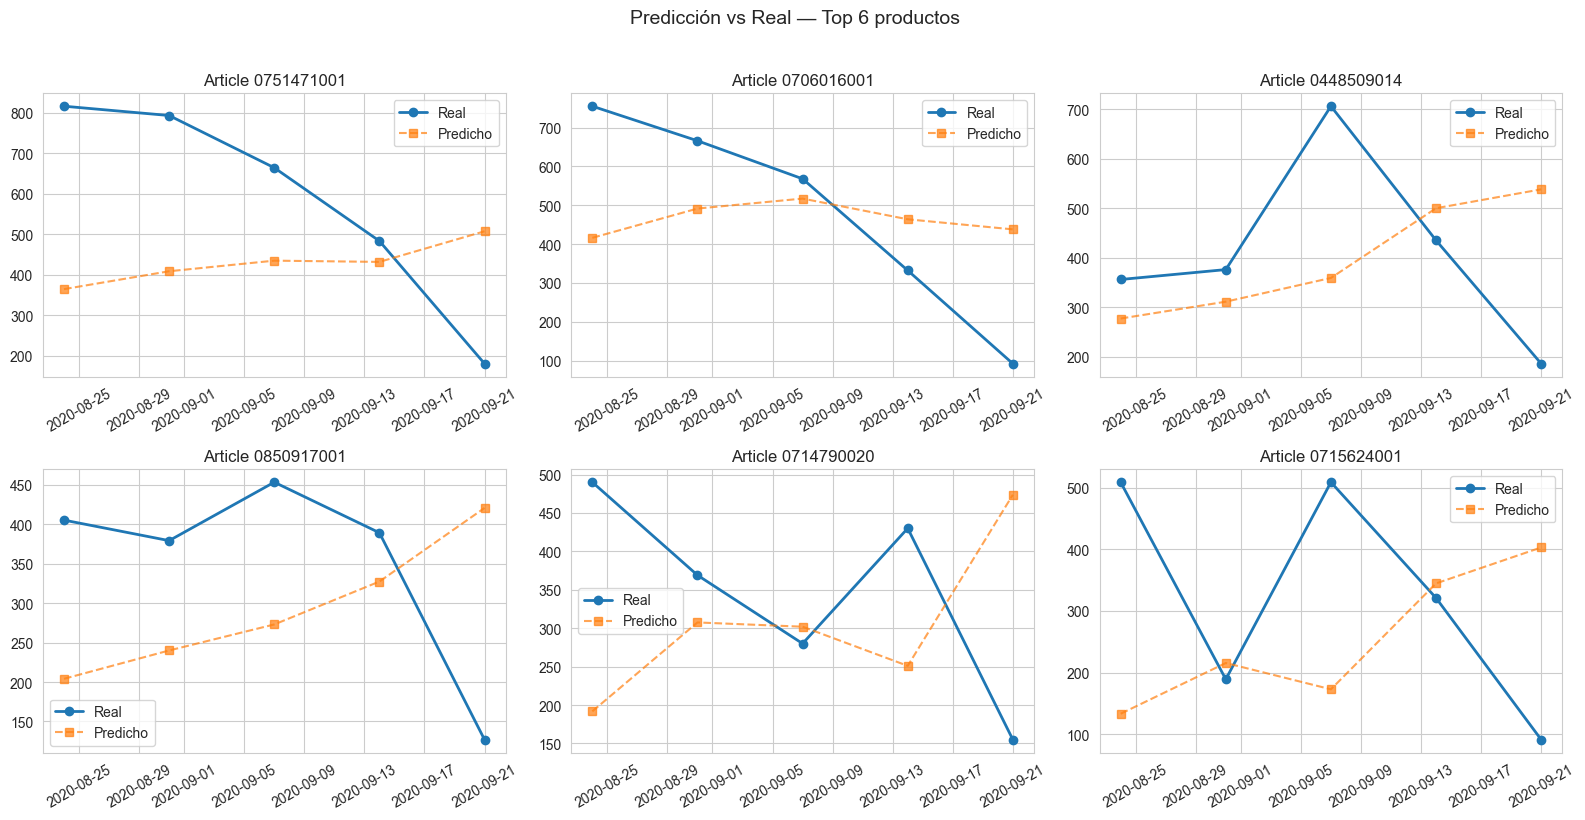

In [13]:
test_with_pred = test.copy()
test_with_pred['y_pred'] = y_pred_lgb

top_articles = (
    test_with_pred.groupby('article_id', observed=True)['units_sold']
    .sum().nlargest(6).index
)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, art_id in zip(axes.flat, top_articles):
    sub = test_with_pred[test_with_pred['article_id'] == art_id].sort_values('week')
    ax.plot(sub['week'], sub['units_sold'], 'o-', label='Real', linewidth=2)
    ax.plot(sub['week'], sub['y_pred'], 's--', label='Predicho', alpha=0.7)
    ax.set_title(f'Article {art_id}')
    ax.legend()
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Predicción vs Real — Top 6 productos', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_demand_predictions_vs_real.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Guardar

In [14]:
predictions_path = PROCESSED_DIR / 'demand_predictions.parquet'
test_with_pred[['article_id', 'week', 'units_sold', 'y_pred', 'avg_price']].to_parquet(
    predictions_path, index=False
)
print(f'✅ Predicciones: {predictions_path}')

metrics_path = RESULTS_DIR / 'demand_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump({'results': results, 'improvement_pct': improvement}, f, indent=2)
print(f'✅ Métricas:     {metrics_path}')

model_path = PROCESSED_DIR / 'demand_model.txt'
model.save_model(str(model_path))
print(f'✅ Modelo:       {model_path}')

✅ Predicciones: C:\Users\esthe\Desktop\fashion-ai-engine\data\processed\demand_predictions.parquet
✅ Métricas:     C:\Users\esthe\Desktop\fashion-ai-engine\reports\results\demand_metrics.json
✅ Modelo:       C:\Users\esthe\Desktop\fashion-ai-engine\data\processed\demand_model.txt


## ✅ Bloque 2 V2 completado

**Siguiente:** `03_return_model.ipynb`